# Semana 8 - LIPAI

Victor Bertolini de Sousa

Dataset: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Github: https://github.com/VictorBertolini/Onboarding-LIPAI

In [167]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [168]:
df_cancer = pd.read_csv("classificacao_supervisionada/data/cancer.csv")
df_cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [169]:
df_cancer.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [170]:
df_cancer = df_cancer.drop(columns=["id", "Unnamed: 32"])

In [171]:
df_cancer["diagnosis"] = df_cancer["diagnosis"].map({"M": 1, "B": 0})

In [172]:
X = df_cancer.drop(columns=["diagnosis"])
y = df_cancer["diagnosis"]

In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [174]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## KNN

In [175]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [176]:
y_pred = model.predict(X_test)

In [177]:
acertos = sum(y_pred == y_test)
total   = len(y_test)
acc     = acertos / total
print(f"Acurácia: {acc:.4f}")

print(f"KNN Acurácia: {acc:.4f}  ({acc*100:.2f}%)")

Acurácia: 0.9474
KNN Acurácia: 0.9474  (94.74%)


In [178]:
VP_knn = sum(1 for r, p in zip(y_test, y_pred) if r == 1 and p == 1)
VN_knn = sum(1 for r, p in zip(y_test, y_pred) if r == 0 and p == 0)
FP_knn = sum(1 for r, p in zip(y_test, y_pred) if r == 0 and p == 1)
FN_knn = sum(1 for r, p in zip(y_test, y_pred) if r == 1 and p == 0)

total_knn     = len(y_test)
acuracia_knn  = (VP_knn + VN_knn) / total
precisao_knn  = VP_knn / (VP_knn + FP_knn)
revocacao_knn = VP_knn / (VP_knn + FN_knn)
fscore_knn    = (2 * precisao_knn * revocacao_knn) / (precisao_knn + revocacao_knn)

In [179]:
print("=" * 35)
print("RESULTADOS")
print("=" * 35)
print(f"  VP (Verdadeiro Positivo) : {VP_knn}")
print(f"  VN (Verdadeiro Negativo) : {VN_knn}")
print(f"  FP (Falso Positivo)      : {FP_knn}")
print(f"  FN (Falso Negativo)      : {FN_knn}")
print("-" * 35)
print(f"  Acurácia  : {acuracia_knn:.4f}  ({acuracia_knn*100:.2f}%)")
print(f"  Precisão  : {precisao_knn:.4f}  ({precisao_knn*100:.2f}%)")
print(f"  Revocação : {revocacao_knn:.4f}  ({revocacao_knn*100:.2f}%)")
print(f"  F-Score   : {fscore_knn:.4f}  ({fscore_knn*100:.2f}%)")
print("=" * 35)

RESULTADOS
  VP (Verdadeiro Positivo) : 40
  VN (Verdadeiro Negativo) : 68
  FP (Falso Positivo)      : 3
  FN (Falso Negativo)      : 3
-----------------------------------
  Acurácia  : 0.9474  (94.74%)
  Precisão  : 0.9302  (93.02%)
  Revocação : 0.9302  (93.02%)
  F-Score   : 0.9302  (93.02%)


## Random Forest

In [180]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [181]:
y_pred = model.predict(X_test)

In [182]:
acertos = sum(y_pred == y_test)
total   = len(y_test)
acc     = acertos / total

print(f"Acertos : {acertos} de {total}")
print(f"Acurácia: {acc:.4f}  ({acc*100:.2f}%)")

Acertos : 110 de 114
Acurácia: 0.9649  (96.49%)


In [183]:
VP_RanFor = sum(1 for r, p in zip(y_test, y_pred) if r == 1 and p == 1)
VN_RanFor = sum(1 for r, p in zip(y_test, y_pred) if r == 0 and p == 0)
FP_RanFor = sum(1 for r, p in zip(y_test, y_pred) if r == 0 and p == 1)
FN_RanFor = sum(1 for r, p in zip(y_test, y_pred) if r == 1 and p == 0)

total_RanFor     = len(y_test)
acuracia_RanFor  = (VP_RanFor + VN_RanFor) / total
precisao_RanFor  = VP_RanFor / (VP_RanFor + FP_RanFor)
revocacao_RanFor = VP_RanFor / (VP_RanFor + FN_RanFor)
fscore_RanFor    = (2 * precisao_RanFor * revocacao_RanFor) / (precisao_RanFor + revocacao_RanFor)

In [184]:
print("=" * 35)
print("RESULTADOS")
print("=" * 35)
print(f"  VP (Verdadeiro Positivo) : {VP_RanFor}")
print(f"  VN (Verdadeiro Negativo) : {VN_RanFor}")
print(f"  FP (Falso Positivo)      : {FP_RanFor}")
print(f"  FN (Falso Negativo)      : {FN_RanFor}")
print("-" * 35)
print(f"  Acurácia  : {acuracia_RanFor:.4f}  ({acuracia_RanFor*100:.2f}%)")
print(f"  Precisão  : {precisao_RanFor:.4f}  ({precisao_RanFor*100:.2f}%)")
print(f"  Revocação : {revocacao_RanFor:.4f}  ({revocacao_RanFor*100:.2f}%)")
print(f"  F-Score   : {fscore_RanFor:.4f}  ({fscore_RanFor*100:.2f}%)")
print("=" * 35)

RESULTADOS
  VP (Verdadeiro Positivo) : 40
  VN (Verdadeiro Negativo) : 70
  FP (Falso Positivo)      : 1
  FN (Falso Negativo)      : 3
-----------------------------------
  Acurácia  : 0.9649  (96.49%)
  Precisão  : 0.9756  (97.56%)
  Revocação : 0.9302  (93.02%)
  F-Score   : 0.9524  (95.24%)


## SVM

In [185]:
model = SVC(kernel="rbf", random_state=42)
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [186]:
y_pred = model.predict(X_test)

In [187]:
acertos = sum(y_pred == y_test)
total   = len(y_test)
acc     = acertos / total

print(f"Acertos : {acertos} de {total}")
print(f"Acurácia: {acc:.4f}  ({acc*100:.2f}%)")

Acertos : 112 de 114
Acurácia: 0.9825  (98.25%)


In [188]:
VP_svm = sum(1 for r, p in zip(y_test, y_pred) if r == 1 and p == 1)
VN_svm = sum(1 for r, p in zip(y_test, y_pred) if r == 0 and p == 0)
FP_svm = sum(1 for r, p in zip(y_test, y_pred) if r == 0 and p == 1)
FN_svm = sum(1 for r, p in zip(y_test, y_pred) if r == 1 and p == 0)

total_svm     = len(y_test)
acuracia_svm  = (VP_svm + VN_svm) / total
precisao_svm  = VP_svm / (VP_svm + FP_svm)
revocacao_svm = VP_svm / (VP_svm + FN_svm)
fscore_svm    = (2 * precisao_svm * revocacao_svm) / (precisao_svm + revocacao_svm)

In [189]:
print("=" * 35)
print("RESULTADOS")
print("=" * 35)
print(f"  VP (Verdadeiro Positivo) : {VP_svm}")
print(f"  VN (Verdadeiro Negativo) : {VN_svm}")
print(f"  FP (Falso Positivo)      : {FP_svm}")
print(f"  FN (Falso Negativo)      : {FN_svm}")
print("-" * 35)
print(f"  Acurácia  : {acuracia_svm:.4f}  ({acuracia_svm*100:.2f}%)")
print(f"  Precisão  : {precisao_svm:.4f}  ({precisao_svm*100:.2f}%)")
print(f"  Revocação : {revocacao_svm:.4f}  ({revocacao_svm*100:.2f}%)")
print(f"  F-Score   : {fscore_svm:.4f}  ({fscore_svm*100:.2f}%)")
print("=" * 35)

RESULTADOS
  VP (Verdadeiro Positivo) : 41
  VN (Verdadeiro Negativo) : 71
  FP (Falso Positivo)      : 0
  FN (Falso Negativo)      : 2
-----------------------------------
  Acurácia  : 0.9825  (98.25%)
  Precisão  : 1.0000  (100.00%)
  Revocação : 0.9535  (95.35%)
  F-Score   : 0.9762  (97.62%)


## Gráfico

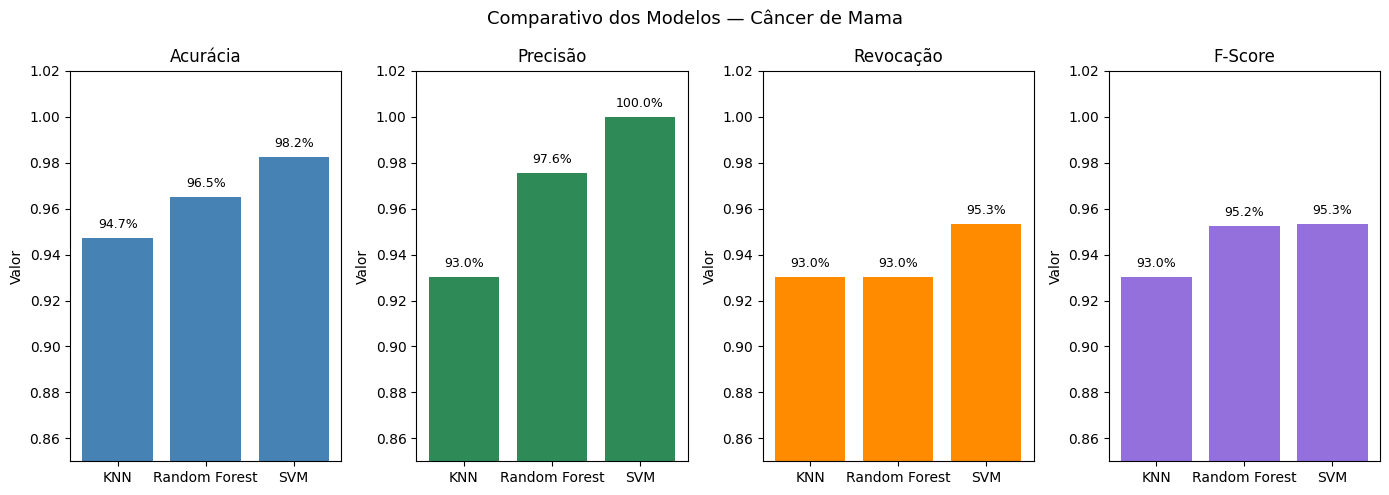

Gráfico salvo!


In [190]:
modelos   = ["KNN", "Random Forest", "SVM"]
acuracia  = [acuracia_knn, acuracia_RanFor, acuracia_svm]
precisao  = [precisao_knn, precisao_RanFor, precisao_svm]
revocacao = [revocacao_knn, revocacao_RanFor, revocacao_svm]
fscore    = [fscore_knn, fscore_RanFor, revocacao_svm]


x = range(len(modelos))

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle("Comparativo dos Modelos — Câncer de Mama", fontsize=13)

metricas = [
    ("Acurácia",  acuracia,  "steelblue"),
    ("Precisão",  precisao,  "seagreen"),
    ("Revocação", revocacao, "darkorange"),
    ("F-Score",   fscore,    "mediumpurple"),
]

for ax, (titulo, valores, cor) in zip(axes, metricas):
    bars = ax.bar(modelos, valores, color=cor)
    ax.set_title(titulo)
    ax.set_ylim(0.85, 1.02)
    ax.set_ylabel("Valor")
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{val*100:.1f}%",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("classificacao_supervisionada/data/grafico_comparativo.png", dpi=150)
plt.show()
print("Gráfico salvo!")

## Reflexões

### Como a escolha do algoritmo influencia o desempenho final?

Cada algoritmo tem uma forma diferente de "aprender". O KNN olha para os vizinhos mais próximos, o Random Forest vota entre várias árvores de decisão, e o SVM tenta encontrar a melhor fronteira entre as classes. A escolha errada pode custar vários pontos de acurácia sem mudar nenhum dado.

## Quais métricas são mais adequadas?

Depende da base de dados e contexto do problema, no que eu escolhi sobre cancer o mais problemático é Falso Negativo, por classificar pacientes com câncer dizendo que não possuem. Então é necessário não só olhar precisão, mas revocacao e f-score também.

## Como a qualidade dos dados pode impactar os resultados?

É o fator mais importante de todos. Dados com valores faltando, colunas irrelevantes ou classes muito desbalanceadas prejudicam qualquer modelo. Se o modelo for treinado com dados ruins, ele aprende os erros e os reproduz na classificação.

## Em quais situações modelos mais simples podem ser mais vantajosos que modelos mais complexos?

Modelos simples podem ser mais vantajosos quando tempo é definitivo, pois são muito mais rápidos de treinar e testar, além de ser mais fáceis de explicar em prática, por exemplo em contextos médicos é melhor algo visível e intuitivo por uma matemática clara, do que redes neurais e modelos pesados que se tornam uma caixa preta que não dá para saber como o modelo aprendeu.

## Resumo Aprendizado Supervisionado

Aprendizado supervisionado é um tipo de aprendizado de máquina em que o modelo aprende usando exemplos já “resolvidos”. Ou seja, ele recebe dados de entrada junto com as respostas corretas e aprende a fazer essa associação

Depois de aprender, ele consegue prever respostas para dados novos que nunca viu antes

O quão bem ele funciona depende muito da qualidade e da quantidade dos dados usados no treinamento

Principais pontos:

Usa dados com rótulos (já sabe a resposta correta)
Aprende padrões para depois fazer previsões

Tipos de problemas:

Classificação: prever categorias
Regressão: prever números

Algoritmos comuns:

- Árvores de decisão
- Random Forest
- SVM
- Redes neurais
- KNN